Import all relevant modules.

In [120]:
import cv2
import os

import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
import os

from moviepy.editor import VideoFileClip
from IPython.display import HTML
from random import choice
from skimage.feature import hog
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
%matplotlib inline

Let's see what the given test images look like.

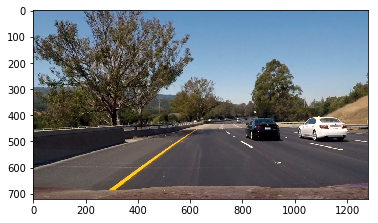

In [4]:
test = plt.imread("test_images/test6.jpg")
plt.imshow(test)

Now let us see an image of a vehicle...

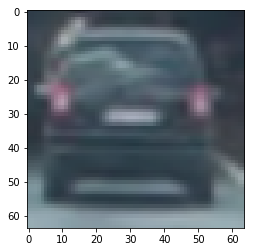

In [6]:
vehicle = plt.imread("datasets/vehicles/GTI_MiddleClose/image0038.png")
plt.imshow(vehicle)

... and an image of a non-vehicle.

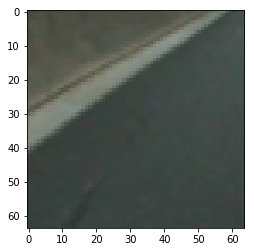

In [8]:
nonvehicle = plt.imread("datasets/non-vehicles/GTI/image2709.png")
plt.imshow(nonvehicle)

Before we train an SVM classifier, we need to write some code to extract HOG features from images.

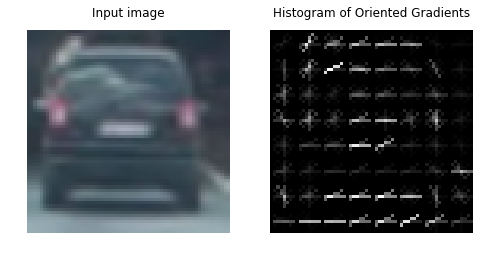

In [33]:
gray = cv2.cvtColor(vehicle, cv2.COLOR_BGR2GRAY)

fd, hog_image = hog(gray, orientations=6, pixels_per_cell=(8, 8),
                    cells_per_block=(2, 2), visualise=True, block_norm='L2-Hys')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4), sharex=True, sharey=True)

ax1.axis('off')
ax1.imshow(vehicle, cmap=plt.cm.gray)
ax1.set_title('Input image')
ax1.set_adjustable('box-forced')

ax2.axis('off')
ax2.imshow(hog_image, cmap=plt.cm.gray)
ax2.set_title('Histogram of Oriented Gradients')
ax1.set_adjustable('box-forced')
plt.show()

In [114]:
def ImageToUnnormalizedFeatures(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    hog_image = hog(
        gray,
        orientations=6,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        block_norm='L2-Hys',
        feature_vector=True
    )
    return hog_image

def FileToUnnormalizedFeatures(filename):
    img = plt.imread(filename)
    return ImageToUnnormalizedFeatures(img)

We now need to list all files containing vehicle- and non-vehicle-images.

In [75]:
def ListRecursivelyWithExtension(topdir, extension):
    out = []
    for dirpath, dirnames, files in os.walk(topdir):
        for name in files:
            if name.lower().endswith(extension):
                out.append(os.path.join(dirpath, name))
    return out

In [78]:
vehicle_imgs = ListRecursivelyWithExtension('./datasets/vehicles', '.png')

In [80]:
non_vehicle_imgs = ListRecursivelyWithExtension('./datasets/non-vehicles', '.png')

We can now create our datasets (first, pre-normalization).

In [86]:
X1 = [FileToUnnormalizedFeatures(filename) for filename in vehicle_imgs]
X2 = [FileToUnnormalizedFeatures(filename) for filename in non_vehicle_imgs]

In [87]:
X = np.concatenate((X1, X2))

In [88]:
y1 = np.ones(len(X1))
y2 = np.zeros(len(X2))
y = np.concatenate((y1, y2))

Before splitting our dataset, we need to normalize it so that all features have mean 0 and variance 1.

In [97]:
X_scaler = StandardScaler().fit(X)
scaled_X = X_scaler.transform(X)

Before fitting the SVM, we split the data into training and validation sets.

In [100]:
X_train, X_test, y_train, y_test = train_test_split(scaled_X, y, test_size=0.1)

We can now train our SVM model.

In [103]:
classifier = SVC()
classifier.fit(X_train, y_train)

SVC(C=1.0, cache_size=200, class_weight=None, coef0=0.0,
  decision_function_shape='ovr', degree=3, gamma='auto', kernel='rbf',
  max_iter=-1, probability=False, random_state=None, shrinking=True,
  tol=0.001, verbose=False)

We now evaluate the model in our validation set.

In [106]:
classifier.score(X_test, y_test)

0.92567567567567566

At this point, we need to implement a sliding-window algorithm to try and figure out where the cars in each image are (in case there are any); this is necessary since we trained our algorithm on an exact crop of cars (in the case of positively-labeled images).

We first display a test video to get some intuition about box sizes.

In [111]:
HTML("""
<video width="960" height="540" controls>
  <source src="{0}">
</video>
""".format('test_video.mp4'))

We also show a randomly chosen test image.

In [127]:
test_images = ListRecursivelyWithExtension('./test_images', '.jpg')

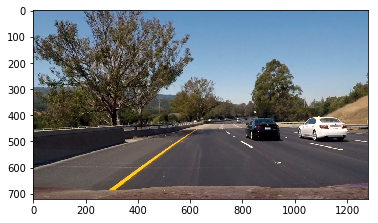

In [141]:
random = plt.imread(choice(test_images))
plt.imshow(random)

We must not forget that, on new images, one must apply normalization before calling the classifier.
As such, we create a wrapper applies the correct preprocessing.

In [115]:
def Preprocess(img):
    x = ImageToUnnormalizedFeatures(img)
    scaled_x = X_scaler.transform(x)
    return x

We use a simple multi-scale sliding window approach. We discard the upper half of the image.

In [147]:
dims = (720, 1280, 3)

def CreateWindows():
    boxes = []
    horizon_y = 400
    min_size = 50
    max_size = 200
    current_height = horizon_y + min_size//2
    current_size = min_size
    max_y = dims[0] - max_size//2
    while (current_height + current_size//2 <= max_y):
        # iterate laterally
        current_width = current_size//2
        max_x = dims[1] - current_size//2
        while (current_width + current_size//2 <= max_x):
            boxes.append(
                (
                    (current_height - current_size//2, current_width - current_size//2),
                    (current_height + current_size//2, current_width + current_size//2)
                )
            )
            current_width += current_size//2 # go right
        current_height += current_size//2 # go down
        # increase box size
        current_size = ((current_height - horizon_y) * max_size + (max_y - current_height) * min_size)//(max_y - horizontal_y)
    return boxes

In [143]:
def draw_boxes(img, bboxes, color=(0, 0, 255), thick=6):
    imcopy = np.copy(img)
    for bbox in bboxes:
        cv2.rectangle(imcopy, bbox[0], bbox[1], color, thick)
    return imcopy

In [148]:
plt.imshow(draw_boxes(random, CreateWindows()))

NameError: name 'horizontal_y' is not defined